# Day 5: 随机森林 — 用 digits 看它为什么比单棵树稳

换了更有挑战的数据集（手写数字，64 维，10 类），对比随机森林和单棵决策树的差距。

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath('..'))
from models.random_forest import RandomForest
from models.decision_tree import DecisionTree

plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

In [10]:
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target
print(f'样本数: {X.shape[0]}, 特征数: {X.shape[1]}, 类别数: {len(digits.target_names)}')

样本数: 1797, 特征数: 64, 类别数: 10


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'训练集: {X_train.shape[0]}, 测试集: {X_test.shape[0]}')

训练集: 1437, 测试集: 360


## 对比：单棵决策树 vs 随机森林

In [12]:
dt = DecisionTree(max_depth=8)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = np.mean(dt_pred == y_test)
print(f'单棵决策树测试准确率: {dt_acc:.4f}')

单棵决策树测试准确率: 0.8639


In [13]:
rf = RandomForest(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = np.mean(rf_pred == y_test)
print(f'随机森林测试准确率: {rf_acc:.4f}')
print(f'提升: {rf_acc - dt_acc:+.4f}')

随机森林测试准确率: 0.9611
提升: +0.0972


### 准确率对比

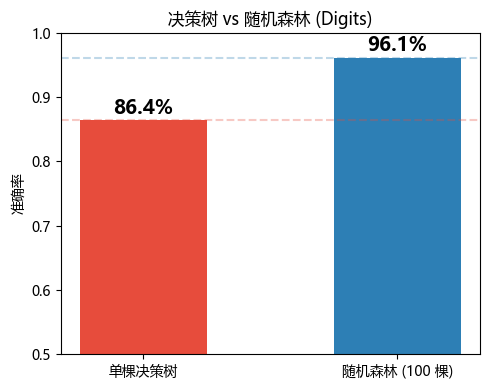

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['单棵决策树', '随机森林 (100 棵)'], [dt_acc, rf_acc],
              color=['#e74c3c', '#2d7fb5'], width=0.5)
ax.set_ylabel('准确率')
ax.set_ylim(0.5, 1.0)
for bar, acc in zip(bars, [dt_acc, rf_acc]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{acc:.1%}', ha='center', fontsize=14, fontweight='bold')
ax.axhline(dt_acc, color='#e74c3c', ls='--', alpha=0.3)
ax.axhline(rf_acc, color='#2d7fb5', ls='--', alpha=0.3)
ax.set_title('决策树 vs 随机森林 (Digits)')
plt.tight_layout()
plt.savefig('../articles/ml/day5_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

### 特征重要性对比

把 64 个像素的重要性还原成 8×8 热力图，看模型在看哪里。

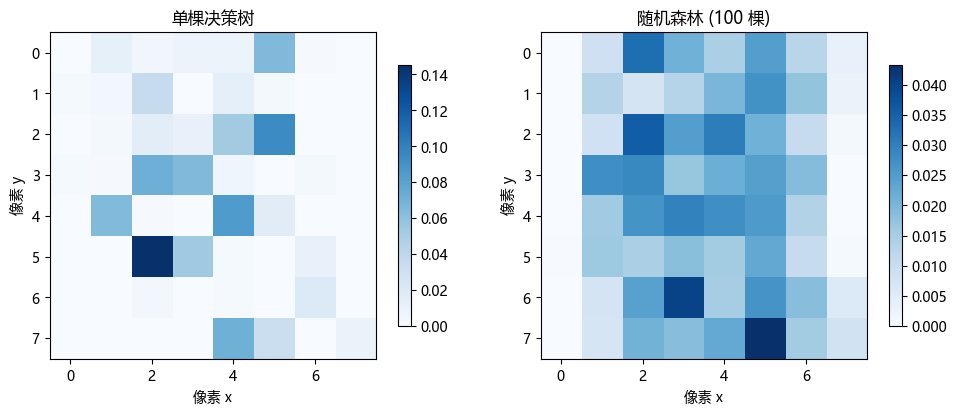

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(dt.feature_importances_.reshape(8, 8), cmap='Blues')
axes[0].set_title('单棵决策树')
axes[0].set_xlabel('像素 x')
axes[0].set_ylabel('像素 y')
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(rf.feature_importances_.reshape(8, 8), cmap='Blues')
axes[1].set_title('随机森林 (100 棵)')
axes[1].set_xlabel('像素 x')
axes[1].set_ylabel('像素 y')
fig.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.savefig('../articles/ml/day5_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

### 与 sklearn 对比验证

In [16]:
from sklearn.ensemble import RandomForestClassifier
sk_rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
sk_rf.fit(X_train, y_train)
sk_pred = sk_rf.predict(X_test)
sk_acc = np.mean(sk_pred == y_test)
print(f'sklearn 测试准确率: {sk_acc:.4f}')
print(f'我们的实现: {rf_acc:.4f}')
print(f'一致率: {np.mean(rf_pred == sk_pred):.4f}')

sklearn 测试准确率: 0.9722
我们的实现: 0.9611
一致率: 0.9556
